<a href="https://colab.research.google.com/github/Vitor-coder-eng/Despertar_da_rede_neural/blob/main/document/Ir_Al%C3%A9m_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FarmTech Solutions🌱**

### Será que uma grande rede pré-treinada em um conjunto de dados imenso performa melhor que uma arquitetura treinada do zero?

### Será que pré-segmentar o objeto de interesse, dando às redes a informação de quais pixels devem ser utilizados na interpretação do conteúdo, facilita a classificação da imagem?
---

Diante disso, é apartir destes questionamentos que iremos desenvolver outras abordagens e arquiteturas. Um projeto de **classificação de imagens usando Transfer Learning, Fine Tuning + segmentação**. O objetivo é explorar técnicas avançadas de classificação de imagens.

 Uma breve descrição dos termos:
- O **Transfer Learning** envolve o uso de um modelo pré-treinado em uma grande base de dados, geralmente em uma tarefa semelhante aquela que estamos enfrentando. O modelo pré-treinado é então ajustado (ou "transferido") para a nova tarefa, mantendo os pesos aprendidos nas camadas mais profundas e ajustando apenas as camadas finais para se adaptarem aos novos dados.
- O **Fine-tuning** é uma técnica que envolve o ajuste fino de um modelo pré-treinado em uma tarefa específica. Isso geralmente envolve o descongelamento de algumas camadas do modelo pré-treinado e o re-treinamento em novos dados. Em outras palavras, é como se a rede fosse retreinada na tarefa de destino, porém com pesos que comprovadamente produzem boas features.
- A **Segmentação** leva a detecção um passo além, pois não apenas localiza o objeto, mas também define sua forma exata em nível de pixel.
---
### Por que fazer isso?

A **FarmTech Solutions** tem uma nova oportunidade de expandir seus projetos de visão computacional, dando continuidade ao nosso cenário entre milhos e raposas. Após o sucesso do sistema desenvolvido para o fazendeiro Tex Willer, o projeto chamou a atenção de outros produtores da região que enfrentam o mesmo problema.

Kit Carson, vizinho e amigo de Tex, entrou em contato relatando uma situação semelhante à que o Sr. Willer vivia. Diante disso, decidimos aproveitar essa nova demanda para testar e comparar diferentes abordagens. Além disso, atualizamos parte do nosso dataset, adicionando imagens mais coerentes com o cenário real — com mais registros de milhos no milharal e raposas em ambientes naturais.

Assim, ao **"ir além do ir além"**, temos a chance de consolidar melhorias no sistema, aprimorar sua precisão e evitar situações como a enfrentada pelo Sr. Carson, ilustrada abaixo.

<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/logofarmtech.png" width="45%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/Kit Carson.png" width="45%" />
</p>

### Conectando no Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Importando algumas bibliotecas necessárias

In [8]:
# Imports necessários
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Desenvolvendo o código fonte para o **Transfer Learning**

In [ ]:
# Caminhos das pastas localizadas no Google Drive
train_dir = "/content/drive/MyDrive/CNN_dataset/train"
val_dir = "/content/drive/MyDrive/CNN_dataset/val"
test_dir = "/content/drive/MyDrive/CNN_dataset/test"

# Geração de dados para treino com aumentos (data augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normaliza os pixels para o intervalo [0, 1]
    rotation_range=20,          # Rotação aleatória de até 20 graus
    width_shift_range=0.2,      # Deslocamento horizontal de até 20%
    height_shift_range=0.2,     # Deslocamento vertical de até 20%
    shear_range=0.2,            # Aplicação de distorção angular (shear)
    zoom_range=0.2,             # Zoom aleatório de até 20%
    horizontal_flip=True        # Inversão horizontal aleatória
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Cria o gerador de imagens de treino a partir do diretório
train_generator = train_datagen.flow_from_directory(
    train_dir,                  # Caminho para o diretório com subpastas por classe
    target_size=(224, 224),     # Redimensiona todas as imagens para 224x224
    batch_size=32,              # Número de imagens por lote
    class_mode='binary'         # Tipo de classificação: binária (duas classes)
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # <- ESSENCIAL
)

# Carregar VGG16 pré-treinado
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar camadas da base
for layer in base_model.layers:
    layer.trainable = False

# Adicionar camadas personalizadas no topo
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Saída para classificação binária

model = Model(inputs=base_model.input, outputs=output)

# Compilar o modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Treinar o modelo
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator
)

# Avaliação do modelo
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no teste: {test_acc:.2f}")

Found 57 images belonging to 2 classes.
Found 14 images belonging to 2 classes.
Found 14 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 54s 34s/step - accuracy: 0.5359 - loss: 1.4548 - val_accuracy: 0.9286 - val_loss: 0.1628
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 25s/step - accuracy: 0.8660 - loss: 0.5029 - val_accuracy: 1.0000 - val_loss: 0.0572
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 45s 29s/step - accuracy: 0.8898 - loss: 0.2288 - val_accuracy: 1.0000 - val_loss: 0.0266
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 26s/step - accuracy: 0.9662 - loss: 0.1140 - val_accuracy: 1.0000 - val_loss: 0.0195
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 51s 28s/step - accuracy: 0.9132 - loss: 0.2105 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 23s/step - accuracy: 1.0000 - loss: 0.0288 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 7/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 45s 28s/step - accuracy: 0.9750 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 0.0261
Epoch 8/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 58s 36s/step - accuracy: 0.8894 - loss: 0.1859 - val_accuracy: 0.9286 - val_loss: 0.0635
1/1 ━━━━

---
<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/VGG_logo.png" width="" />

---

## A Escolha da Arquitetura VGG para o Transfer Learning
  Criada pelo Visual Geometry Group, departamento de ciências e engenharia da Universidade de Oxford. A arquitetura VGG16 segue uma estrutura simples e padronizada, composta por blocos de camadas convolucionais com filtros 3x3, ativação ReLU e camadas de MaxPooling 2x2 para redução da dimensionalidade. Os blocos aumentam gradativamente o número de filtros (64, 128, 256, 512), e ao final, a rede possui duas camadas densas de 4096 neurônios seguidas de uma camada de saída. No nosso projeto, adaptamos essa última camada para uma saída binária com ativação sigmoid. Sua profundidade (16 camadas com pesos treináveis) e alto número de parâmetros tornam essencial o uso de Transfer Learning e Data Augmentation em conjuntos de dados pequenos, como o nosso.

---
<img src="https://upload.wikimedia.org/wikipedia/commons/2/24/VGG16.png" width="">

---

## Data Augmentation

Como citado acima, nossa base de dados é relativamente pequena. Modelos como o VGG costumam demandar uma grande quantidade de dados para treinar com eficácia. Por isso, aplicamos **Data Augmentation**, uma técnica que consiste em aumentar artificialmente o tamanho e volume dos dados. Realizamos transformações como rotação, deslocamento horizontal e vertical, distorção, zoom e inversão.

---

## Camadas Congeladas

Para evitar o treinamento completo da rede, utilizamos o seguinte critério:

```python
for layer in base_model.layers:
    layer.trainable = False
```
Isso é chamado de feature extraction, onde usamos a base da rede pré-treinada apenas como extratora de características e não a atualizamos.

### Conferindo qual classe pertence a qual número

In [ ]:
print(test_generator.class_indices)


{'corn': 0, 'fox': 1}


### Gerando Matriz de Confusão

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


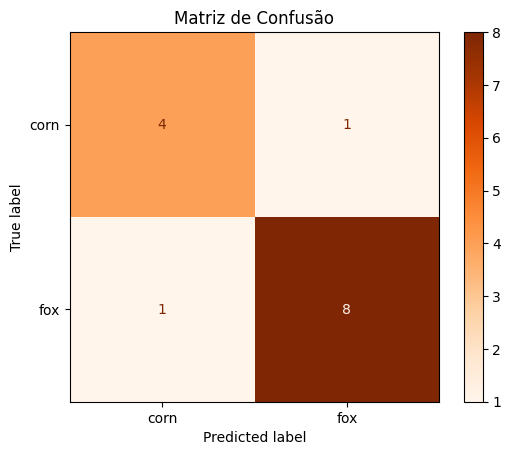

In [ ]:
# Gerar as previsões
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)  # Converte para 0 ou 1

# Obter os rótulos verdadeiros
y_true = test_generator.classes
# Gerar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names = ['corn', 'fox']

# Exibir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusão")
plt.show()

### Observando a estrutura do modelo importado

In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### **Fine Tuning**

In [ ]:
# Descongelar algumas das últimas camadas da base VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Recompilar o modelo com uma taxa de aprendizado menor
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Menor taxa de aprendizado!
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Re-treinar o modelo (agora com Fine Tuning)
fine_tune_history = model.fit(
    train_generator,
    epochs=4,
    validation_data=val_generator
)

# Avaliação do modelo
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no teste: {test_acc:.2f}")

Epoch 1/4
2/2 ━━━━━━━━━━━━━━━━━━━━ 61s 32s/step - accuracy: 0.9324 - loss: 0.1619 - val_accuracy: 1.0000 - val_loss: 0.0158
Epoch 2/4
2/2 ━━━━━━━━━━━━━━━━━━━━ 64s 45s/step - accuracy: 0.9883 - loss: 0.0313 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 3/4
2/2 ━━━━━━━━━━━━━━━━━━━━ 58s 31s/step - accuracy: 0.9662 - loss: 0.1164 - val_accuracy: 1.0000 - val_loss: 0.0175
Epoch 4/4
2/2 ━━━━━━━━━━━━━━━━━━━━ 59s 38s/step - accuracy: 0.9633 - loss: 0.0845 - val_accuracy: 1.0000 - val_loss: 0.0198
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.9286 - loss: 0.7892
Acurácia no teste: 0.93


### Gerando Matriz de Confusão

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


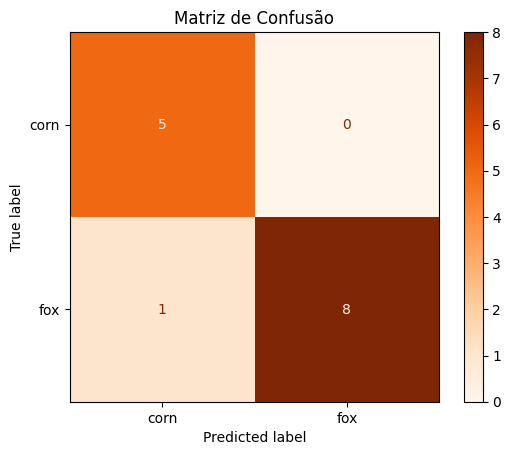

In [ ]:
# 1. Gerar as previsões
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)  # Converte para 0 ou 1

# 2. Obter os rótulos verdadeiros
y_true = test_generator.classes
# 3. Gerar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names = ['corn', 'fox']

# 4. Exibir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusão")
plt.show()

### Análise Crítica e Comparações

"Vamos voltar um pouco no tempo?"
  **Será que uma grande rede pré-treinada em um conjunto de dados imenso performa melhor que uma arquitetura treinada do zero?**
  Este foi o questionamento norteador do nosso estudo. Para respondê-lo, propomos uma comparação entre dois modelos: uma CNN construída do zero e uma arquitetura VGG16 com Transfer Learning e Fine Tuning.

 **Etapas Realizadas:**

 - Treinamento de uma CNN do zero

 - Transfer Learning com VGG16

 - Fine Tuning

 - Comparações de desempenho (acurácia, matriz de confusão e tempo)

**Resultados do Trasfer Learning:**

    Acurácia: 86%

    Matriz de confusão:

     [4, 1]
     [1, 8]

    Épocas: 8 (quantidade pequena para evitar overfitting, dado o modelo já pré-treinado, também
    levando em consideração que a CNN treinada do zero teve um bom desempenho com apenas 10 épocas)


 **Fine Tuning**

Após o primeiro teste com Transfer Learning, aplicamos Fine Tuning descongelando as 4 últimas camadas convolucionais da VGG16, permitindo um leve ajuste dos pesos para nossa base.

**Resultados:**

    Acurácia: 93%

    Matriz de confusão:

     [5, 0]
     [1, 8]

    Épocas: 4 (apenas para ajuste fino sem sobreajustar)

A melhora foi perceptível, porém, um olhar desatento poderia julgar o nosso modelo como **quase** bom, o que demonstra um erro e certa qualidade em ambientes extremamente controlados como o nosso. Um cálculo rápido. Nossa base teste tem 14 imagens. 9 para a classe fox e 5 para a classe corn.

$$
\text{Acurácia} = \frac{\text{Total de acertos}}{\text{Total de amostras}} = \frac{5 + 8}{5 + 0 + 1 + 8} = \frac{13}{14} \approx 0{,}9286 \Rightarrow 92{,}86\% \Rightarrow 93\%
$$


**Agora vamos interpretar essa matriz de confusão um pouco mais de perto:**

- 5 imagens de corn foram corretamente classificadas como corn ✅

- 0 imagens de corn foram classificadas como fox ✅

- 8 imagens de fox foram corretamente classificadas como fox ✅

- 1 imagem de fox foi classificada incorretamente como corn ❌


É neste "erro" que temos que nos atentar. Um Teste interessante foi o uso de uma imagem contendo dois objetos, mas o modelo só foi treinado pra fazer classificação binária: fox ou corn. Ele precisa decidir por uma... então ele fez uma escolha plausível baseada nos padrões que aprendeu. E acertou, de certo modo.

<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/Matriz de Confusão.png" width="45%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/Fox.png" width="40%" />
</p>

**Isso mostra que:**

  - O modelo está sensível aos padrões dos dois objetos;

  - Ele não foi enganado por ruído visual;

  - Ele tem um ótimo poder de generalização mesmo em situações ambíguas.

**Próximo nível?**

Este tipo de insight nos dá margem pra pensar em Multi-label classification, onde a imagem pode conter mais de uma classe (ex: tanto corn quanto fox).

**Tempo de Execução, Eficiência e Conclusões Finais: CNN do Zero 🆚 Transfer Learning**

    CNN do zero:
    Tempo de execução rápido (em segundos), poucos parâmetros (~30 mil).

    VGG16:
    Tempo muito mais alto (~8 minutos por treinamento), com 14.7 milhões de parâmetros, a maioria não-treinável.

Isso reflete o custo computacional de se trabalhar com modelos de grande porte, mesmo que pré-treinados, principalmente quando a base é pequena. A vantagem é que o modelo já parte com um "conhecimento" robusto — que pode ser refinado com pouco ajuste. A comparação evidencia que, sim, uma grande rede pré-treinada tende a performar melhor que uma arquitetura treinada do zero, desde que seja aplicada com as técnicas corretas (congelamento, ajuste fino, e data augmentation).

Contudo, é importante ponderar os recursos computacionais disponíveis e a natureza do problema antes de decidir entre um modelo do zero ou uma arquitetura transferida. Nossa base é relativamente pequena e nosso objetivo simples, classificar dois objetos. Por tanto, usar um Trasnfer learning e fine tuning em um problema como o nosso, pode se tirar a conclusão de uso desnecessário de recursos computacionais e tempo, também levando em consideração o bom desempenho da CNN desenvolvida na Entrega 2.

# **Segmentação**

### Instalando o modelo com os pesos e as dependências necessárias para segmentação

In [ ]:
# Instalar dependências do SAM
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-80miq0ff
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-80miq0ff
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=61738c6b22e3464a00bfebef2c9c8f8f3d7b9105010825f17953a5e90bce4749
  Stored in directory: /tmp/pip-ephem-wheel-cache-oucbah1q/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything


In [ ]:
# Clonar o repositório com os pesos do modelo
!git clone https://github.com/facebookresearch/segment-anything.git
%cd segment-anything

Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 304 (delta 2), reused 1 (delta 1), pack-reused 299 (from 2)
Receiving objects: 100% (304/304), 18.31 MiB | 15.96 MiB/s, done.
Resolving deltas: 100% (159/159), done.
/content/segment-anything


In [ ]:
# Baixar pesos pré-treinados (usa MobileSAM por ser mais leve pro Colab)
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2025-04-22 01:39:41--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 108.157.254.124, 108.157.254.121, 108.157.254.102, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|108.157.254.124|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  17.1MB/s    in 5.8s    

2025-04-22 01:39:47 (62.1 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



---
<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/meta_logo.png" width="45%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/cat.png" width="42%" />
</p>

---
## A Escolha do Modelo SAM para Segmentação

Desenvolvido pela Meta, o modelo de segmentação SAM (Segment Anything Model) é uma ferramenta poderosa e considerado um dos modelos mais modernos de segmentação de imagens, que permite isolar objetos com alta precisão a partir de simples interações, como pontos ou caixas delimitadoras. Sua aplicação neste projeto tem como objetivo segmentar as imagens da nossa base teste. Assim, facilitar o trabalho da rede de classificação, fazendo ela olhar apenas para a área da imagem que contém informações relevantes, ou seja, os objetos a serem classificados.

---
## Metodologia

A metodologia adotada nesta parte consiste, inicialmente, na segmentação e análise de uma imagem individual da base de dados, a fim de validar a eficácia do processo de segmentação. Em seguida, as técnicas são aplicadas de forma abrangente a todo o conjunto de dados de teste, permitindo uma avaliação mais robusta dos resultados obtidos.

---


### Carregando a imagem original que iremos segmentar

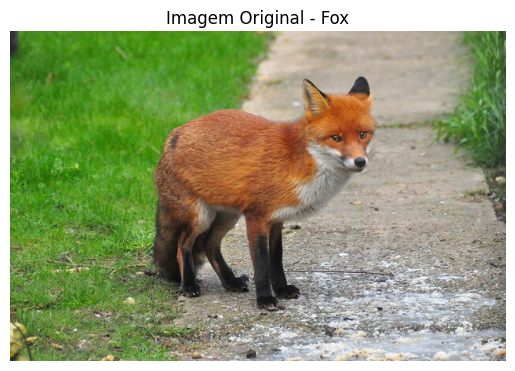

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Caminho da imagem de exemplo
img_path = "/content/drive/MyDrive/CNN_dataset/test/fox/photo 46.png"

# Carrega a imagem
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.title("Imagem Original - Fox")
plt.show()


### Definindo qual objeto a ser segmentado

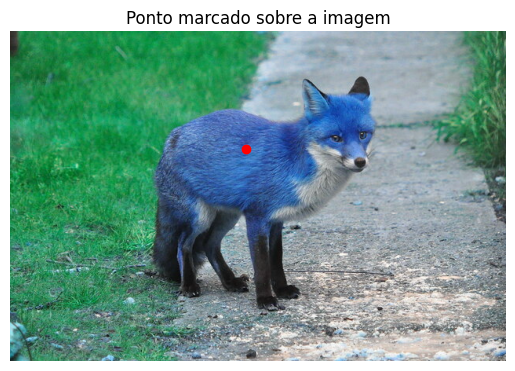

In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"

# Registra e carrega o modelo
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)

predictor = SamPredictor(sam)

# Exibir a imagem com os pontos específicos marcado manualmente
# OBS: Fui testando até encontrar o centro do objeto

x = 300  # coordenada horizontal
y = 150  # coordenada vertical

plt.imshow(image)
plt.scatter([x], [y], color='red')  # Marca o ponto dado ao SAM
plt.title("Ponto marcado sobre a imagem")
plt.axis('off')
plt.show()


### Aplicando a máscara de segmentação

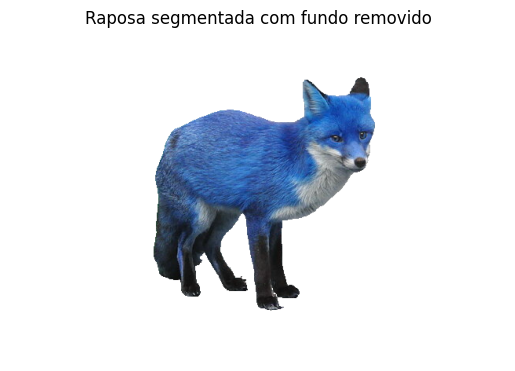

In [ ]:
# Converte máscara para booleano
mask = masks[0]

segmented_image = image.copy()
segmented_image[~mask] = 255


# Exibe a imagem segmentada
plt.imshow(segmented_image)
plt.title("Raposa segmentada com fundo removido")
plt.axis("off")
plt.show()


### Mas, por que azul?

Por padrão, o modelo SAM aplica uma máscara de segmentação sobre a região da imagem segmentada — e a cor azul geralmente é escolhida. Em termos técnicos, após o ponto marcado com as coordenadas, o SAM retorna uma máscara binária (0 = fundo, 1 = objeto), e quando nós visualizamos isso, geralmente o código de exibição usa uma função que sobrepõe essa máscara com uma transparência (alpha) e uma cor, muitas vezes azul ou ciano, para facilitar a visualização.

Essa máscara pode ser usada para:

  - Recortar o objeto da imagem original;

  - Aplicar filtros;

  - Criar uma nova imagem só com o objeto;

Após entendermos como a rede SAM trabalha, podemos segmentar toda a base teste.

### Código fonte para segmentação das imagens em toda a base de teste

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import Image
import torch

# Caminho para a pasta 'test'
test_dir = "/content/drive/MyDrive/CNN_dataset/test"

# Caminho para a pasta onde o modelo irá salvar as imagens segmentadas
save_dir = "/content/drive/MyDrive/CNN_dataset/segmented/test"

# Configurações
device = "cuda" if torch.cuda.is_available() else "cpu"
sam_checkpoint = "/content/segment-anything/sam_vit_b_01ec64.pth"
model_type = "vit_b"

# Carregar e registrar o modelo SAM
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device)
predictor = SamPredictor(sam)

# Função para segmentar a imagem
def segment_image(image_path):
    # Carregar a imagem
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)

    # Antes de passar os pontos para o predictor, converta-os para numpy
    point_coords = np.array([[0, 0]])  # Exemplo de ponto
    point_labels = [1]  # Exemplo de label

    # Definir a imagem no SAM
    predictor.set_image(image_array)

    # Obter a máscara
    masks, _, _ = predictor.predict(point_coords=point_coords, point_labels=point_labels)

    # Ajustar a máscara para a dimensão da imagem
    mask = masks[0]  # Máscara gerada
    mask_resized = np.resize(mask, (image_array.shape[0], image_array.shape[1]))  # Redimensiona a máscara
    mask_resized = np.expand_dims(mask_resized, axis=-1)  # Expande para ter 1 canal

    # Garantir que a máscara tenha 3 canais (para combinar com a imagem)
    mask_resized = np.repeat(mask_resized, 3, axis=-1)  # Expande para 3 canais

    # Aplicar a máscara na imagem original
    segmented_image = np.where(mask_resized, 255, image_array)  # Aplica a máscara, fundo branco

    return segmented_image

#Define a função segment_image_and_save
#Ela chama segment_image para obter a imagem segmentada e a salva no caminho especificado
def segment_image_and_save(image_path, save_path):
    segmented_image = segment_image(image_path)
    segmented_pil = Image.fromarray(segmented_image.astype(np.uint8))
    segmented_pil.save(save_path)

# Processar imagens
for class_name in ['corn', 'fox']:
    class_dir = os.path.join(test_dir, class_name)
    save_class_dir = os.path.join(save_dir, class_name)
    os.makedirs(save_class_dir, exist_ok=True)

    for image_name in os.listdir(class_dir):
        if image_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(class_dir, image_name)
            save_path = os.path.join(save_class_dir, image_name)
            segment_image_and_save(image_path, save_path) # Chama a função correta: segment_image_and_save

### Exibindo uma imagem após a segmentação

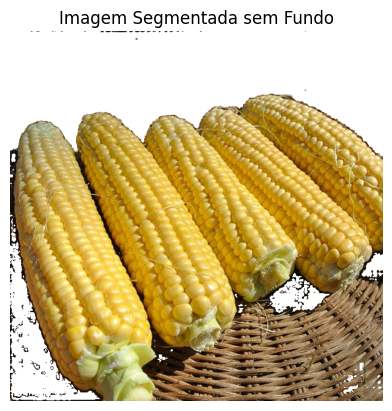

In [ ]:
image_path = "/content/drive/MyDrive/CNN_dataset/segmented/test/corn/photo 37.png"
segmented_image = segment_image(image_path)

plt.imshow(segmented_image)
plt.title("Imagem Segmentada sem Fundo")
plt.axis('off')
plt.show()



### Atualização da Base, Contextualização Visual e  Análise da segmentação

Como citado no início, para tornar o experimento mais desafiador e coerente com um cenário realista, atualizamos a base de imagens com exemplos que reforçam o contexto natural e ambíguo das classes fox e corn. Substituímos imagens mais simples (como "milho na manteiga" e "raposas em estúdio") por imagens capturadas em ambientes naturais, camufladas, com baixa resolução e presença de ruídos visuais.

**Essa curadoria teve como objetivo:**

  - Testar o poder de generalização do modelo de segmentação;

  - Adicionar complexidade à tarefa de classificação;

  - Tornar o experimento mais alinhado com problemas reais de visão computacional.

---
**Exemplos de imagens retiradas do dataset:**

<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/MM.png" width="42%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/FF.png" width="35%" />
</p>

---

**Exemplos das novas imagens adicionadas no dataset:**
<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 51.png" width="42%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 44c.png" width="34%" />
</p>
<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 41.png" width="43%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 44.png" width="34%" />
</p>

---
**Análise da Segmentação**

**Durante a aplicação do modelo SAM sobre as novas imagens da base teste, observamos os seguintes pontos:**

 - Classe "Corn": O modelo teve mais dificuldade em segmentar áreas específicas. Muitas imagens mostravam grandes milharais onde a cena inteira representava a classe. Nesses casos, o SAM segmentou pequenas regiões irrelevantes (como trechos do céu e pequenos fundos), o que é compreensível, já que não havia um único objeto de interesse destacado.
  <p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 45s.png" width="42%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 38s.png" width="42%" />
</p>



  - Classe "Fox": A performance foi visivelmente mais clara. Mesmo em imagens com baixa resolução e raposas camufladas entre vegetação, o modelo conseguiu identificar os contornos principais, inclusive em uma imagem onde apenas a cabeça da raposa era visível, pequena e parcialmente escondida — resultado surpreendente e promissor.

**Abaixo, destacamos as duas imagens citadas (pré e pós-segmentada) para ilustrar visualmente o impacto do modelo:**

<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 48.png" width="43%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 48s.png" width="43%" />
</p>

**Outros exemplos de imagens segmentadas da classe "Fox":**

<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 53s.png" width="42%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 40_1s.png" width="44%" />
</p>

---

**Segmentação Isolada vs Segmentação em Lote**

Ao comparar uma imagem segmentada de forma isolada — que apresentou resultado impecável — com a mesma imagem processada em conjunto com o restante da base, notamos uma queda na qualidade da segmentação. Isso levanta questionamentos relevantes:

  - A diferença está nas coordenadas escolhidas para os pontos de segmentação?

  - A forma como o código foi estruturado para segmentar múltiplas imagens impactou a precisão?

  - Seria necessário algum tipo de refinamento no ponto de entrada (prompting)?

**Exemplo visual da segmentação isolada a esquerda e a segmentação em lote a direita:**
<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 46.png" width="41%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/photo 46s.png" width="43%" />
</p>

**Confira as principais comparações na tabela abaixo**

| Aspecto                   | Segmentação Solo                                         | Segmentação em Lote                                              |
|---------------------------|----------------------------------------------------------|------------------------------------------------------------------|
| **Seleção de ponto**      | Teste manual de coordenadas (x, y) até centrar<br>a raposa, garantindo foco. | Uso de ponto fixo [0,0] em todas as imagens; pode gerar<br>segmentações imprecisas. |
| **Prompting**             | **Interativo:** ajuste fino via inspeção visual.         | **Automático:** mesmas coordenadas padrão, sem refinamento.     |
| **Dimensionamento**       | Redimensionamento garantido com o tamanho exato da imagem. | Uso de `np.resize`, que pode distorcer a máscara<br>em proporções diferentes. |
| **Salvamento**            | Apenas exibição gráfica durante testes.                  | Salva em disco nas pastas corn e fox.                      |
| **Robustez geral**        | Alta (prompt manual e preciso).                          | Média/baixa (prompt genérico e possível distorção).              |


**Perspectivas Futuras**

**Para aprimorar a segmentação em lote e alcançar resultados comparáveis ao método manual, algumas estratégias podem ser exploradas:**

- **Prompt Dinâmico Automatizado**: calcular automaticamente pontos de interesse, como o centroide de regionprops em binarizações prévias, para fornecer prompts mais relevantes ao SAM.
- **Segmentação Multi-Prompt**: combinar múltiplos pontos ou bounding boxes por imagem e mesclar as máscaras resultantes para cobrir melhor objetos complexos.
- **Modelos Especializados**: treinar um modelo de segmentação específico (ex: U-Net ou DeepLab) com máscaras geradas pelo SAM como rótulo inicial, criando assim um sistema híbrido mais robusto.
- **Pós-processamento de Máscaras**: aplicar técnicas de morfologia matemática (erosão, dilatação) e filtragem de contornos para refinar bordas e remover ruídos.
- **Fine-Tuning do SAM**: ajustar (“fine-tune”) o próprio modelo SAM em um subconjunto anotado do dataset, adaptando-o às características específicas de raposas e milharais.

Essas abordagens podem elevar a qualidade da segmentação em lote, reduzindo ruídos e garantindo maior precisão antes da classificação.

---

**Mas por que agora não está azul?**

Ao exibir a segmentação diretamente com a máscara aplicada via  `plt.imshow(segmented_image) `, o objeto aparece azul por padrão devido ao colormap usado na visualização. No entanto, ao salvar as imagens segmentadas, especialmente após aplicar a máscara sobre a imagem original  `segmented_image = np.where(mask_resized, 255, image_array)`, o resultado visual não mantém a coloração azul — e isso é esperado.

O que importa para o modelo de classificação é a máscara binária que define quais pixels pertencem ao objeto de interesse. A cor exibida é apenas uma forma de visualização humana, sem impacto prático na etapa seguinte.

### Reaplicando o modelo de classificação com Transfer Learning, agora com os testes definidos para a base segmentada

In [ ]:
# Caminhos das pastas localizadas no Google Drive
train_dir = "/content/drive/MyDrive/CNN_dataset/train"
val_dir = "/content/drive/MyDrive/CNN_dataset/val"
test_dir = "/content/drive/MyDrive/CNN_dataset/segmented/test" # Caminho ajustado para a base de teste segmentada

# Geração de dados para treino com aumentos (data augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normaliza os pixels para o intervalo [0, 1]
    rotation_range=20,          # Rotação aleatória de até 20 graus
    width_shift_range=0.2,      # Deslocamento horizontal de até 20%
    height_shift_range=0.2,     # Deslocamento vertical de até 20%
    shear_range=0.2,            # Aplicação de distorção angular (shear)
    zoom_range=0.2,             # Zoom aleatório de até 20%
    horizontal_flip=True        # Inversão horizontal aleatória
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Cria o gerador de imagens de treino a partir do diretório
train_generator = train_datagen.flow_from_directory(
    train_dir,                  # Caminho para o diretório com subpastas por classe
    target_size=(224, 224),     # Redimensiona todas as imagens para 224x224 (compatível com VGG)
    batch_size=32,              # Número de imagens por lote
    class_mode='binary'         # Tipo de classificação: binária (duas classes)
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # <- ESSENCIAL
)

# Carregar VGG16 pré-treinado
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar camadas da base
for layer in base_model.layers:
    layer.trainable = False

# Adicionar camadas personalizadas no topo
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Saída para classificação binária

model = Model(inputs=base_model.input, outputs=output)

# Compilar o modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Treinar o modelo
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator
)

# Avaliação do modelo
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no teste: {test_acc:.2f}")

Found 57 images belonging to 2 classes.
Found 14 images belonging to 2 classes.
Found 14 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 49s 29s/step - accuracy: 0.5343 - loss: 0.8320 - val_accuracy: 0.5714 - val_loss: 2.0801
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 83s 26s/step - accuracy: 0.6294 - loss: 1.9443 - val_accuracy: 0.9286 - val_loss: 0.1191
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 29s/step - accuracy: 0.8147 - loss: 0.3982 - val_accuracy: 0.9286 - val_loss: 0.2576
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 25s/step - accuracy: 0.7867 - loss: 0.5320 - val_accuracy: 1.0000 - val_loss: 0.0191
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 29s/step - accuracy: 0.9132 - loss: 0.2185 - val_accuracy: 0.9286 - val_loss: 0.1184
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 25s/step - accuracy: 0.8999 - loss: 0.2945 - val_accuracy: 0.9286 - val_loss: 0.1242
Epoch 7/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 46s 25s/step - accuracy: 0.8335 - loss: 0.4113 - val_accuracy: 1.0000 - val_loss: 0.0126
Epoch 8/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 48s 26s/step - accuracy: 0.9441 - loss: 0.1871 - val_accuracy: 1.0000 - val_loss: 0.0194
1/1 ━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127805 (\N{EAR OF MAIZE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129418 (\N{FOX FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


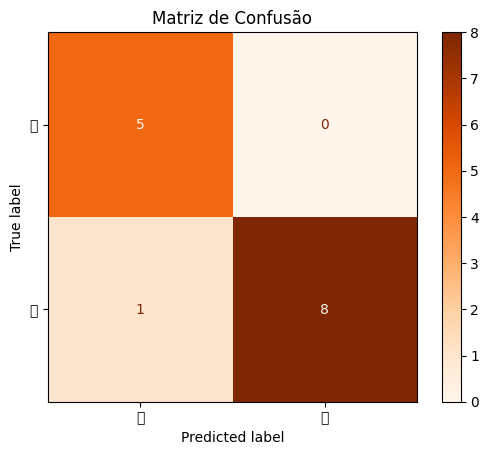

In [ ]:
# 1. Gerar as previsões
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)  # Converte para 0 ou 1

# 2. Obter os rótulos verdadeiros
y_true = test_generator.classes
# 3. Gerar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names = ['Cor', 'Fox']

# 4. Exibir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusão")
plt.show()

**Análise da Classificação com Imagens Segmentadas**


**Lembra do nosso segundo questionamento norteador neste projeto?**

> **"Será que pré-segmentar o objeto de interesse, dando às redes a informação de quais pixels devem ser utilizados na interpretação do conteúdo, facilita a classificação da imagem?"**

Após aplicar novamente a rede de classificação, agora utilizando as imagens segmentadas previamente pelo SAM, os resultados obtidos foram, surpreendentemente, **idênticos** aos da versão anterior: tanto em termos de **acurácia** quanto na **matriz de confusão**.

Esse comportamento nos traz um insight semelhante ao que já havíamos observado anteriormente, quando comparamos o fine-tuning de uma CNN com uma rede treinada do zero: **sim, a abordagem mais inteligente pode funcionar melhor — mas tudo depende do contexto**. No nosso caso:

- A base de dados continua **relativamente pequena**;
- As imagens são, em sua maioria, capturadas em um ambiente **altamente controlado**;
- Os objetos principais (raposa e milho) ainda são **facilmente reconhecíveis** mesmo com ruído no fundo.

Portanto, a segmentação não prejudicou o modelo, mas também **não trouxe ganhos significativos** — pelo menos, nesse cenário.


**Proposta de Encerramento e Validação Final**

Para reforçar nossa análise, propomos agora uma última modificação: **apagar a imagem ambígua (a raposa com o milho na boca) da nossa base teste**.

**A hipótese é clara:**
> Ao isolar por completo os objetos de interesse, a rede deverá apresentar **acurácia de 100%** e uma **matriz de confusão perfeita**, evidenciando o total controle dos dados em nosso cenário. Este teste também reforça a necessidade de contextualização, entendimento do negócio e instiga a pesquisa com algumas palavras norteadoras:

- "Depende do objetivo."
- "Por que estamos fazendo isso?"
  



### Reaplicando o modelo de classificação com Transfer Learning com os testes definidos para a base segmentada, agora sem a imagem ambígua

In [9]:
# Caminhos das pastas localizadas no Google Drive
train_dir = "/content/drive/MyDrive/CNN_dataset/train"
val_dir = "/content/drive/MyDrive/CNN_dataset/val"
test_dir = "/content/drive/MyDrive/CNN_dataset/segmented/test"

# Geração de dados para treino com aumentos (data augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Normaliza os pixels para o intervalo [0, 1]
    rotation_range=20,          # Rotação aleatória de até 20 graus
    width_shift_range=0.2,      # Deslocamento horizontal de até 20%
    height_shift_range=0.2,     # Deslocamento vertical de até 20%
    shear_range=0.2,            # Aplicação de distorção angular (shear)
    zoom_range=0.2,             # Zoom aleatório de até 20%
    horizontal_flip=True        # Inversão horizontal aleatória
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Cria o gerador de imagens de treino a partir do diretório
train_generator = train_datagen.flow_from_directory(
    train_dir,                  # Caminho para o diretório com subpastas por classe
    target_size=(224, 224),     # Redimensiona todas as imagens para 224x224
    batch_size=32,              # Número de imagens por lote
    class_mode='binary'         # Tipo de classificação: binária (duas classes)
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # <- ESSENCIAL
)

# Carregar VGG16 pré-treinado
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar camadas da base
for layer in base_model.layers:
    layer.trainable = False

# Adicionar camadas personalizadas no topo
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Saída para classificação binária

model = Model(inputs=base_model.input, outputs=output)

# Compilar o modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Treinar o modelo
history = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator
)

# Avaliação do modelo
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no teste: {test_acc:.2f}")

Found 57 images belonging to 2 classes.
Found 14 images belonging to 2 classes.
Found 13 images belonging to 2 classes.
Epoch 1/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.4629 - loss: 2.0001 - val_accuracy: 0.5714 - val_loss: 1.2760
Epoch 2/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5488 - loss: 1.6674 - val_accuracy: 0.7857 - val_loss: 0.3934
Epoch 3/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6749 - loss: 0.7381 - val_accuracy: 1.0000 - val_loss: 0.0982
Epoch 4/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 861ms/step - accuracy: 0.9324 - loss: 0.2793 - val_accuracy: 1.0000 - val_loss: 0.1026
Epoch 5/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 839ms/step - accuracy: 0.7997 - loss: 0.3515 - val_accuracy: 1.0000 - val_loss: 0.0700
Epoch 6/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9649 - loss: 0.1537 - val_accuracy: 1.0000 - val_loss: 0.0391
Epoch 7/8
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 844ms/step - accuracy: 0.8999 - loss: 0.1740 - val_accuracy: 1.0000 - val_loss: 0.0273
Epoch 8/8
2/2 ━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step


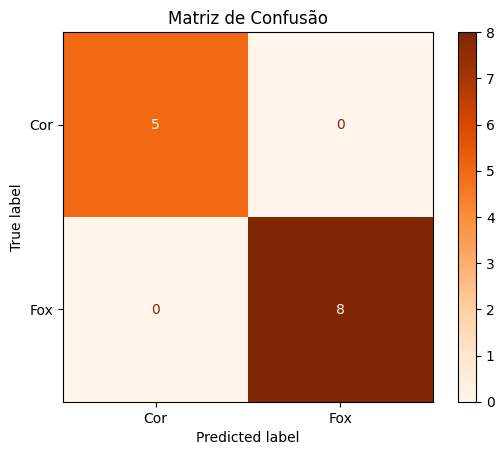

In [10]:
# 1. Gerar as previsões
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)  # Converte para 0 ou 1

# 2. Obter os rótulos verdadeiros
y_true = test_generator.classes
# 3. Gerar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names = ['Cor', 'Fox']

# 4. Exibir
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Oranges')
plt.title("Matriz de Confusão")
plt.show()

**Nota do autor:**

Enquanto pensava nas soluções para este trabalho, olhei para o lado do meu computador e vi algumas HQs do Tex sobre a mesa. Isso me inspirou a contextualizar melhor as análises, simulando um ambiente real, aprimorando a experiência do leitor e contando histórias através dos dados. Algumas imagens ilustrativas deste projeto, como Tex Willer, Kit Carson e a raposa sorrateira no milharal, foram geradas com o auxílio de inteligência artificial.

<p align="center">
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/logofarmtech.png" width="50%" />
  <img src="https://raw.githubusercontent.com/Vitor-coder-eng/Despertar_da_rede_neural/main/assets/fim.png" width="42%" />
</p>